<a href="https://colab.research.google.com/github/Brayanlira98/Telecom_X/blob/main/Challenge_Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introducción

Telecom X Análisis de Evasión de Clientes

El presente trabajo analiza un conjunto de datos de la empresa Telecom X en el marco del proyecto “Churn de Clientes”, cuyo objetivo es identificar y comprender los factores que influyen en la alta tasa de cancelaciones por parte de los clientes.

Para el análisis se utilizará el lenguaje de programación Python y diversas bibliotecas especializadas en análisis de datos y generación de visualizaciones, como Pandas y Matplotlib. Estas herramientas permitirán identificar patrones, relaciones y posibles correlaciones entre las variables, con el propósito de proponer estrategias orientadas a la reducción de la evasión de clientes.

#Limpieza y Tratamiento de Datos

##Tratamiento de la base de datos

###Importando datos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



In [ ]:
import pandas as pd
datos=pd.read_json("https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json")
datos

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


###Normalizando columnas

In [ ]:
datos = pd.json_normalize(datos.to_dict(orient="records"))
datos

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


###Analizando el tipo de dato de cada columna

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

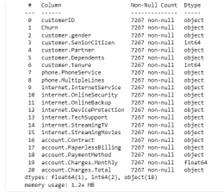

La informacion muestra que la tabla no tiene datos nulos y se compone de datos tipo object,int64 y float64. Sin embargo, la columna 20 en lugar de tipo object deberia ser de tipo float64.

###Buscando caracteres en columna 20

Se buscaron que caracteres no son de tipo float para poderlos modificar

In [ ]:
a=datos[datos["account.Charges.Total"].astype(str).str.contains(r"[^0-9.\-]", regex=True)]

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total


Se identificaron elementos en la columna 20 que no contenian ningun caracter.
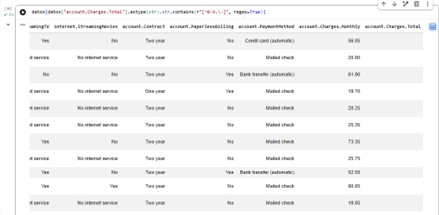

###Modificacion de los datos

Se modificaron los filas que no contenian datos por el valor "0" en la columna 20.

In [ ]:
datos["account.Charges.Total"]=datos["account.Charges.Total"].str.replace(" ","0",regex=True)
datos[datos["account.Charges.Total"].astype(str).str.contains(r"[^0-9.\-]", regex=True)]

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total


Para confirmar que se realizo la modificacion correcta se volvio a buscar los elementos de la columna 20 que no contenian elementos tipo float y el resultado indico que ya no exsitian elementos.

###Modificando el tipo de dato

In [ ]:
datos["account.Charges.Total"]=datos["account.Charges.Total"].astype('float64')

In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

###Verificando clientes duplicados en la base de datos

In [ ]:
datos.customerID.nunique()

7267

Dado que la columna customerID contiene 7267 elmentos y el metodo nunique() nos indica que dicha columna contiene 7267 elemntos diferentes quiere decir que no existen elemntos duplicados.

###Explorando que las otras columnas no tengan inconsistencias

####Columna Churn

In [ ]:
print(datos["Churn"].nunique())
print(datos["Churn"].unique())
datos.query(' Churn ==""')

3
['No' 'Yes' 'unknown']


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias


Se identifico que la columna debria solo tener elementos "No" o "Yes" pero tiene 224 elementos faltantes los cuales se replazaran por el string siguiente "unknown" que implica que la informacion es desconocida.

In [ ]:
datos["Churn"]=datos["Churn"].str.replace(" ","unknown",regex=True)
print(datos["Churn"].nunique())
print(datos["Churn"].unique())
datos.query(' Churn =="unknown"')

3
['No' 'Yes' 'unknown']


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
30,0047-ZHDTW,unknown,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.30
75,0120-YZLQA,unknown,Male,0,No,No,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.10
96,0154-QYHJU,unknown,Male,0,No,No,29,Yes,No,DSL,...,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.20
98,0162-RZGMZ,unknown,Female,1,No,No,5,Yes,No,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,unknown,Male,1,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,unknown,Female,0,No,No,14,Yes,Yes,DSL,...,Yes,No,No,No,No,One year,Yes,Mailed check,54.25,773.20
7180,9872-RZQQB,unknown,Female,0,Yes,No,49,No,No phone service,DSL,...,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
7211,9920-GNDMB,unknown,Male,0,No,No,9,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85
7239,9955-RVWSC,unknown,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.90


####Columna customer.gender

In [ ]:
print(datos["customer.gender"].nunique())
print(datos["customer.gender"].unique())

2
['Female' 'Male']


Esta columna no necesita modificacion por que no tiene elemntos faltantes y toos los datos se clasifican en las 2 categorias posibles.

####Columna customer.SeniorCitizen

In [ ]:
print(datos["customer.SeniorCitizen"].nunique())
print(datos["customer.SeniorCitizen"].unique())

2
[0 1]


Esta columna no necesita modificacion por que no tiene elemntos faltantes y toos los datos se clasifican en las 2 categorias posibles.

####Columna customer.Partner

In [ ]:
print(datos["customer.Partner"].nunique())
print(datos["customer.Partner"].unique())

2
['Yes' 'No']


Esta columna no necesita modificacion por que no tiene elemntos faltantes y toos los datos se clasifican en las 2 categorias posibles.

####Columna customer.Dependents

In [ ]:
print(datos["customer.Dependents"].nunique())
print(datos["customer.Dependents"].unique())

2
[1 0]


Esta columna no necesita modificacion por que no tiene elemntos faltantes y toos los datos se clasifican en las 2 categorias posibles.

####Columna customer.tenure

In [ ]:
datos["customer.tenure"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7267 entries, 0 to 7266
Series name: customer.tenure
Non-Null Count  Dtype
--------------  -----
7267 non-null   int64
dtypes: int64(1)
memory usage: 56.9 KB


Esta columna no necesita modificaciones, no tiene elementos nulos y todos son tipo int64

#### Columna phone.PhoneService

In [ ]:
print(datos["phone.PhoneService"].nunique())
print(datos["phone.PhoneService"].unique())

2
['Yes' 'No']


Esta columna no necesita modificacion por que no tiene elemntos faltantes y toos los datos se clasifican en las 2 categorias posibles.

####Columna phone.MultipleLines

In [ ]:
print(datos["phone.MultipleLines"].nunique())
print(datos["phone.MultipleLines"].unique())
datos[datos["phone.PhoneService"] == "No"]
datos.query("`phone.PhoneService` == 'No'")


3
['No' 'Yes' 'No phone service']


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
10,0017-DINOC,No,Male,0,No,No,54,No,No phone service,DSL,...,No,No,Yes,Yes,No,Two year,No,Credit card (automatic),45.20,2460.55
14,0019-GFNTW,No,Female,0,No,No,56,No,No phone service,DSL,...,Yes,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),45.05,2560.10
16,0020-JDNXP,No,Female,0,Yes,Yes,34,No,No phone service,DSL,...,No,Yes,Yes,Yes,Yes,One year,No,Mailed check,61.25,1993.20
19,0023-HGHWL,Yes,Male,1,No,No,1,No,No phone service,DSL,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,25.10,25.10
25,0032-PGELS,Yes,Female,0,Yes,Yes,1,No,No phone service,DSL,...,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),30.50,30.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7200,9906-NHHVC,No,Female,1,No,No,65,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),53.50,3517.90
7201,9907-SWKKF,Yes,Female,1,No,No,1,No,No phone service,DSL,...,No,No,No,No,No,Month-to-month,No,Mailed check,25.05,25.05
7218,9928-BZVLZ,No,Female,0,No,No,12,No,No phone service,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,49.85,552.10
7238,9955-QOPOY,No,Male,0,Yes,No,69,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),60.80,4263.40


Esta columna no necesita modificacion por que no tiene elemntos faltantes y toos los datos se clasifican en las 3 categorias posibles.

#### Columna internet.InternetService

In [ ]:
print(datos["internet.InternetService"].nunique())
print(datos["internet.InternetService"].unique())

3
['DSL' 'Fiber optic' 'No']


Esta columna no necesita modificacion por que no tiene elementos faltantes y toos los datos se clasifican en las 3 categorias posibles.

####Columna internet.OnlineSecurity

In [ ]:
print(datos["internet.OnlineSecurity"].nunique())
print(datos["internet.OnlineSecurity"].unique())

3
['No' 'Yes' 'No internet service']


Esta columna no necesita modificacion por que no tiene elementos faltantes y toos los datos se clasifican en las 3 categorias posibles.

####Columna internet.OnlineBackup

In [ ]:
print(datos["internet.OnlineBackup"].nunique())
print(datos["internet.OnlineBackup"].unique())

3
['Yes' 'No' 'No internet service']


Esta columna no necesita modificacion por que no tiene elementos faltantes y toos los datos se clasifican en las 3 categorias posibles.

#### Columna internet.DeviceProtection

In [ ]:
print(datos["internet.DeviceProtection"].nunique())
print(datos["internet.DeviceProtection"].unique())

3
['No' 'Yes' 'No internet service']


Esta columna no necesita modificacion por que no tiene elementos faltantes y toos los datos se clasifican en las 3 categorias posibles.

#### Columna internet.TechSupport

In [ ]:
print(datos["internet.TechSupport"].nunique())
print(datos["internet.TechSupport"].unique())

3
['Yes' 'No' 'No internet service']


Esta columna no necesita modificacion por que no tiene elementos faltantes y toos los datos se clasifican en las 3 categorias posibles.

#### Columna internet.StreamingTV

In [ ]:
print(datos["internet.StreamingTV"].nunique())
print(datos["internet.StreamingTV"].unique())

3
['Yes' 'No' 'No internet service']


Esta columna no necesita modificacion por que no tiene elementos faltantes y toos los datos se clasifican en las 3 categorias posibles.

####Columna internet.StreamingMovies

In [ ]:
print(datos["internet.StreamingMovies"].nunique())
print(datos["internet.StreamingMovies"].unique())

3
['No' 'Yes' 'No internet service']


Esta columna no necesita modificacion por que no tiene elementos faltantes y toos los datos se clasifican en las 3 categorias posibles.

#### Columna account.Contract

In [ ]:
print(datos["account.Contract"].nunique())
print(datos["account.Contract"].unique())

3
['One year' 'Month-to-month' 'Two year']


Esta columna no necesita modificacion por que no tiene elementos faltantes y toos los datos se clasifican en las 3 categorias posibles.

####Columna account.PaperlessBilling

In [ ]:
print(datos["account.PaperlessBilling"].nunique())
print(datos["account.PaperlessBilling"].unique())

2
['Yes' 'No']


Esta columna no necesita modificacion por que no tiene elementos faltantes y toos los datos se clasifican en las 2 categorias posibles.

#### Columna account.PaymentMethod

In [ ]:
print(datos["account.PaymentMethod"].nunique())
print(datos["account.PaymentMethod"].unique())

4
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


Esta columna no necesita modificacion por que no tiene elementos faltantes y toos los datos se clasifican en las 4 categorias posibles.

#### Columna account.Charges.Monthly

In [ ]:
datos["account.Charges.Monthly"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7267 entries, 0 to 7266
Series name: account.Charges.Monthly
Non-Null Count  Dtype  
--------------  -----  
7267 non-null   float64
dtypes: float64(1)
memory usage: 56.9 KB


Esta columna no necesita modificaciones, no tiene elementos nulos y todos son tipo float64

#### Columna account.Charges.Total

In [ ]:
datos["account.Charges.Total"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7267 entries, 0 to 7266
Series name: account.Charges.Total
Non-Null Count  Dtype  
--------------  -----  
7267 non-null   float64
dtypes: float64(1)
memory usage: 56.9 KB


Esta columna no necesita modificaciones, no tiene elementos nulos y todos son tipo float64

##Añadiendo nueva columna "Cuentas_Diarias"

In [ ]:
datos_limpios=datos
datos_limpios

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


Para crear la nueva columna se usa la información total de todos los servicios del cliente por mes en la columna (account.Charges.Monthly). Dichos valores se multiplican por 12, que es la cantidad de meses en un año y se divide entre 365 que son los dias en un año. Con esto se obtiene la cantidad diaria que el cliente paga.

In [ ]:
datos_limpios["Cuentas_Diarias"]=(datos_limpios["account.Charges.Monthly"]*12)/365
datos_limpios

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.156712
1,0003-MKNFE,No,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.969315
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.429589
3,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.221918
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.758356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.813151
7263,9992-RRAMN,Yes,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.797808
7264,9992-UJOEL,No,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.653699
7265,9993-LHIEB,No,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.230685


##Estandarización y transformación de datos

In [ ]:
Datos_a_estandarizar=datos_limpios
Datos_a_estandarizar

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.156712
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.969315
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.429589
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.221918
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.758356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.813151
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.797808
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.653699
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.230685


In [ ]:
Columnas_Object=Datos_a_estandarizar.select_dtypes(include=["object"])
print(len(Columnas_Object.columns))
for i in range (len(Columnas_Object.columns)-1):
   print(f"indice= {i+1},{Columnas_Object.columns[i+1]},{Columnas_Object[Columnas_Object.columns[i+1]].unique()}")

#Columnas_Object.columns[1:]


17
indice= 1,Churn,['No' 'Yes' 'unknown']
indice= 2,customer.gender,['Female' 'Male']
indice= 3,customer.Partner,['Yes' 'No']
indice= 4,customer.Dependents,['Yes' 'No']
indice= 5,phone.PhoneService,['Yes' 'No']
indice= 6,phone.MultipleLines,['No' 'Yes' 'No phone service']
indice= 7,internet.InternetService,['DSL' 'Fiber optic' 'No']
indice= 8,internet.OnlineSecurity,['No' 'Yes' 'No internet service']
indice= 9,internet.OnlineBackup,['Yes' 'No' 'No internet service']
indice= 10,internet.DeviceProtection,['No' 'Yes' 'No internet service']
indice= 11,internet.TechSupport,['Yes' 'No' 'No internet service']
indice= 12,internet.StreamingTV,['Yes' 'No' 'No internet service']
indice= 13,internet.StreamingMovies,['No' 'Yes' 'No internet service']
indice= 14,account.Contract,['One year' 'Month-to-month' 'Two year']
indice= 15,account.PaperlessBilling,['Yes' 'No']
indice= 16,account.PaymentMethod,['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


Se observa que de las columnas que son de tipo object algunas solo manejas 2 tipo de dato "Yes" y "No", se decidio intercambiar los datos de esas columnas por 1 y 0 en ese orden. Tambien se intercambio "No phone service" y "No internet service" por 0. Las otras columnas se dejaron igual.

In [ ]:
Datos_intercambiados=Datos_a_estandarizar
Datos_intercambiados[['customer.Partner','customer.Dependents','phone.PhoneService','phone.MultipleLines','internet.OnlineSecurity','internet.OnlineBackup','internet.DeviceProtection','internet.TechSupport','internet.StreamingTV','internet.StreamingMovies','account.PaperlessBilling']]=Datos_intercambiados[['customer.Partner','customer.Dependents','phone.PhoneService','phone.MultipleLines','internet.OnlineSecurity','internet.OnlineBackup','internet.DeviceProtection','internet.TechSupport','internet.StreamingTV','internet.StreamingMovies','account.PaperlessBilling']].replace('Yes',1).replace('No',0).replace('No phone service',0).replace('No internet service',0)
Datos_intercambiados

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.156712
1,0003-MKNFE,No,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.969315
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.429589
3,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.221918
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.758356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.813151
7263,9992-RRAMN,Yes,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.797808
7264,9992-UJOEL,No,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.653699
7265,9993-LHIEB,No,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.230685


In [ ]:
Datos_intercambiados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   int64  
 5   customer.Dependents        7267 non-null   int64  
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   int64  
 8   phone.MultipleLines        7267 non-null   int64  
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   int64  
 11  internet.OnlineBackup      7267 non-null   int64  
 12  internet.DeviceProtection  7267 non-null   int64  
 13  internet.TechSupport       7267 non-null   int64

In [ ]:
Datos_intercambiados["customerID"]
Datos_intercambiados.iloc[:,5]

,customer.Dependents
0,1
1,0
2,0
3,0
4,0
...,...
7262,0
7263,0
7264,0
7265,1


#Análisis Exploratorio de Datos

##Análisis Descriptivo

In [ ]:
Datos_intercambiados[["Churn","customer.gender","internet.InternetService","account.Contract","account.PaymentMethod"]].describe()

,Churn,customer.gender,internet.InternetService,account.Contract,account.PaymentMethod
count,7267,7267,7267,7267,7267
unique,3,2,3,3,4
top,No,Male,Fiber optic,Month-to-month,Electronic check
freq,5174,3675,3198,4005,2445


In [ ]:
Datos_intercambiados.describe()

,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2277.182035,2.127784
std,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.648587,0.990561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.600000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,396.200000,1.164658
50%,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1389.200000,2.311233
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3778.525000,2.954795
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.904110


##Distribución de evasión

In [ ]:
Evasion=Datos_intercambiados["Churn"].value_counts()
Evasion_final=Evasion.reset_index()
Evasion_final

,Churn,count
0,No,5174
1,Yes,1869
2,unknown,224


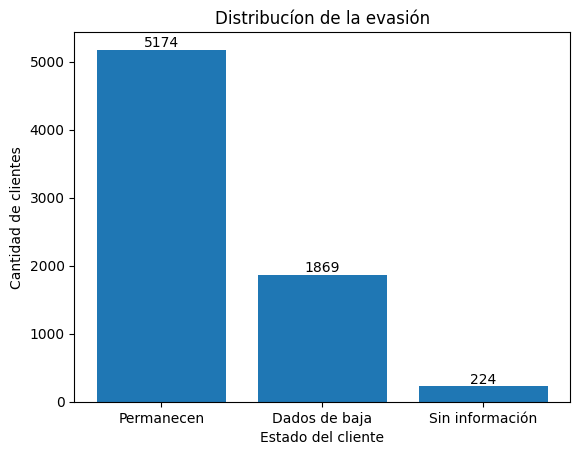

In [ ]:
plt.bar(Evasion_final["Churn"],Evasion_final["count"])
plt.xlabel("Estado del cliente")
plt.ylabel("Cantidad de clientes")
plt.title("Distribucíon de la evasión")
plt.xticks(['No','Yes','unknown'],['Permanecen','Dados de baja','Sin información'])
for i, valor in enumerate (Evasion_final["count"]):
  plt.text(i,valor+1,str(valor),ha='center',va='bottom')
plt.show()

##Recuento de evasión por variables categóricas

In [ ]:
Datos_intercambiados

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.156712
1,0003-MKNFE,No,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.969315
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.429589
3,0011-IGKFF,Yes,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.221918
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.758356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,0,0,13,1,0,DSL,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.813151
7263,9992-RRAMN,Yes,Male,0,1,0,22,1,1,Fiber optic,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.797808
7264,9992-UJOEL,No,Male,0,0,0,2,1,0,DSL,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.653699
7265,9993-LHIEB,No,Male,0,1,1,67,1,0,DSL,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.230685


In [ ]:
Recuento1=Datos_intercambiados[["Churn","customer.gender"]]
Recuento1.groupby(['Churn','customer.gender']).value_counts()

Churn    customer.gender
No       Female             2549
         Male               2625
Yes      Female              939
         Male                930
unknown  Female              104
         Male                120
Name: count, dtype: int64

In [ ]:
Recuento2=Datos_intercambiados[["Churn","internet.InternetService"]]
Recuento2.groupby(['Churn','internet.InternetService']).value_counts()

Churn    internet.InternetService
No       DSL                         1962
         Fiber optic                 1799
         No                          1413
Yes      DSL                          459
         Fiber optic                 1297
         No                           113
unknown  DSL                           67
         Fiber optic                  102
         No                            55
Name: count, dtype: int64

In [ ]:
Recuento3=Datos_intercambiados[["Churn","account.Contract"]]
Recuento3.groupby(['Churn','account.Contract']).value_counts()

Churn    account.Contract
No       Month-to-month      2220
         One year            1307
         Two year            1647
Yes      Month-to-month      1655
         One year             166
         Two year              48
unknown  Month-to-month       130
         One year              46
         Two year              48
Name: count, dtype: int64

In [ ]:
Recuento4=Datos_intercambiados[["Churn","account.PaymentMethod"]]
Recuento4.groupby(['Churn','account.PaymentMethod']).value_counts()

Churn    account.PaymentMethod    
No       Bank transfer (automatic)    1286
         Credit card (automatic)      1290
         Electronic check             1294
         Mailed check                 1304
Yes      Bank transfer (automatic)     258
         Credit card (automatic)       232
         Electronic check             1071
         Mailed check                  308
unknown  Bank transfer (automatic)      45
         Credit card (automatic)        46
         Electronic check               80
         Mailed check                   53
Name: count, dtype: int64

##Conteo de evasión por variables numéricas

In [ ]:
Recuento5=Datos_intercambiados[["Churn","customer.SeniorCitizen"]]
Recuento5.groupby(['Churn','customer.SeniorCitizen']).value_counts()

Churn    customer.SeniorCitizen
No       0                         4508
         1                          666
Yes      0                         1393
         1                          476
unknown  0                          184
         1                           40
Name: count, dtype: int64

In [ ]:
Recuento6=Datos_intercambiados[["Churn","customer.Partner"]]
Recuento6.groupby(['Churn','customer.Partner']).value_counts()

Churn    customer.Partner
No       0                   2441
         1                   2733
Yes      0                   1200
         1                    669
unknown  0                    108
         1                    116
Name: count, dtype: int64

In [ ]:
Recuento7=Datos_intercambiados[["Churn","customer.Dependents"]]
Recuento7.groupby(['Churn','customer.Dependents']).value_counts()

Churn    customer.Dependents
No       0                      3390
         1                      1784
Yes      0                      1543
         1                       326
unknown  0                       153
         1                        71
Name: count, dtype: int64

In [ ]:
Recuento8=Datos_intercambiados[["Churn","customer.tenure"]]
Recuento8.groupby(['Churn','customer.tenure']).value_counts()

Churn    customer.tenure
No       0                   11
         1                  233
         2                  115
         3                  106
         4                   93
                           ... 
unknown  68                   4
         69                   5
         70                   3
         71                   6
         72                   7
Name: count, Length: 209, dtype: int64

In [ ]:
Recuento9=Datos_intercambiados[["Churn","phone.PhoneService"]]
Recuento9.groupby(['Churn','phone.PhoneService']).value_counts()

Churn    phone.PhoneService
No       0                      512
         1                     4662
Yes      0                      170
         1                     1699
unknown  0                       25
         1                      199
Name: count, dtype: int64

In [ ]:
Recuento10=Datos_intercambiados[["Churn","phone.MultipleLines"]]
Recuento10.groupby(['Churn','phone.MultipleLines']).value_counts()

Churn    phone.MultipleLines
No       0                      3053
         1                      2121
Yes      0                      1019
         1                       850
unknown  0                       130
         1                        94
Name: count, dtype: int64

In [ ]:
Recuento11=Datos_intercambiados[["Churn","internet.OnlineSecurity"]]
Recuento11.groupby(['Churn','internet.OnlineSecurity']).value_counts()

Churn    internet.OnlineSecurity
No       0                          3450
         1                          1724
Yes      0                          1574
         1                           295
unknown  0                           165
         1                            59
Name: count, dtype: int64

In [ ]:
Recuento12=Datos_intercambiados[["Churn","internet.OnlineBackup"]]
Recuento12.groupby(['Churn','internet.OnlineBackup']).value_counts()

Churn    internet.OnlineBackup
No       0                        3268
         1                        1906
Yes      0                        1346
         1                         523
unknown  0                         149
         1                          75
Name: count, dtype: int64

In [ ]:
Recuento13=Datos_intercambiados[["Churn","internet.DeviceProtection"]]
Recuento13.groupby(['Churn','internet.DeviceProtection']).value_counts()

Churn    internet.DeviceProtection
No       0                            3297
         1                            1877
Yes      0                            1324
         1                             545
unknown  0                             155
         1                              69
Name: count, dtype: int64

In [ ]:
Recuento14=Datos_intercambiados[["Churn","internet.TechSupport"]]
Recuento14.groupby(['Churn','internet.TechSupport']).value_counts()

Churn    internet.TechSupport
No       0                       3440
         1                       1734
Yes      0                       1559
         1                        310
unknown  0                        164
         1                         60
Name: count, dtype: int64

In [ ]:
Recuento15=Datos_intercambiados[["Churn","internet.StreamingTV"]]
Recuento15.groupby(['Churn','internet.StreamingTV']).value_counts()

Churn    internet.StreamingTV
No       0                       3281
         1                       1893
Yes      0                       1055
         1                        814
unknown  0                        141
         1                         83
Name: count, dtype: int64

In [ ]:
Recuento16=Datos_intercambiados[["Churn","internet.StreamingMovies"]]
Recuento16.groupby(['Churn','internet.StreamingMovies']).value_counts()

Churn    internet.StreamingMovies
No       0                           3260
         1                           1914
Yes      0                           1051
         1                            818
unknown  0                            140
         1                             84
Name: count, dtype: int64

In [ ]:
Recuento17=Datos_intercambiados[["Churn","account.PaperlessBilling"]]
Recuento17.groupby(['Churn','account.PaperlessBilling']).value_counts()

Churn    account.PaperlessBilling
No       0                           2403
         1                           2771
Yes      0                            469
         1                           1400
unknown  0                             84
         1                            140
Name: count, dtype: int64

#Conclusiones e Insights

Los datos recopilados en el análisis muestran que los hallazgos más significativos son los siguientes:

El 26.53% de los clientes se dio de baja, lo cual representa un porcentaje considerablemente alto. Esto indica que el problema requiere atención prioritaria.

Se observa una posible relación entre la cancelación del servicio y el internet por fibra óptica, ya que la mayoría de los clientes que se dieron de baja contaban con esta modalidad.

Otro parámetro relevante es el método de pago mediante cheque electrónico, el cual presenta una mayor incidencia entre los clientes que abandonaron el servicio.

El 25.46% de los clientes que cancelaron tenía 65 años o más, mientras que solo el 12.87% de los clientes que permanecen en la empresa pertenece a este rango de edad. Esto sugiere una posible relación entre la edad y la probabilidad de cancelación.

Entre los clientes que se dieron de baja, la mayoría no tenía pareja.

En general, se observa que los clientes que cancelaron el servicio contaban, en proporción, con menos servicios adicionales contratados en comparación con aquellos que continúan con la empresa.


#Recomendaciones

De acuerdo con las conclusiones obtenidas, se proponen las siguientes recomendaciones para la empresa:

Es necesario revisar el servicio de internet por fibra óptica, tanto en lo referente a su infraestructura como a la experiencia del cliente, con el fin de mejorar su calidad y confiabilidad.

También se recomienda optimizar el método de pago mediante cheque electrónico, garantizando que todos los canales de pago sean eficientes, seguros y fáciles de utilizar, evitando así posibles inconvenientes para los clientes.

Otra estrategia para fortalecer la permanencia de los clientes consiste en prestar especial atención a las necesidades de aquellos que tienen 65 años o más, ya que una cuarta parte de los clientes que cancelaron pertenece a este rango de edad. Para ello, es importante recopilar información más detallada sobre sus expectativas, preferencias y posibles motivos de insatisfacción.

Finalmente, se sugiere fortalecer la oferta de servicios adicionales. En particular, podrían diseñarse paquetes que integren varios servicios a un mismo costo, brindando mayor valor percibido y una mejor experiencia general, lo que podría contribuir a incrementar la permanencia de los clientes.